# **RAVDESS DATASET**

Ryerson Audio-Visual Database of Emotional Speech and Song

---

The dataset includes 1,440 audio files featuring 24 professional actors (12 females and 12 males). These actors performed two lexically-matched statements in a neutral North American accent, expressing eight emotions: Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, and Surprised. Each emotion was conveyed at two intensity levels (Normal and Strong), and was repeated twice by each actor to ensure consistency and reliability.

In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os
import librosa
from IPython import display as ipd

%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf

### Data Processing

In [3]:
# Import python file/module functions.py
from data_process import DataProcess
process = DataProcess()

In [16]:
# Create DataFrame with index `File_Name`
df = pd.read_csv('audio.csv')
# df.set_index('File_Name', inplace=True)

In [20]:
# Show current DF
df.head()

,File_Name,Actor,Gender,Emotion,Intensity,Statement,Repetition
60,03-01-01-01-01-01-02.wav,2,F,neutral,normal,1,1
61,03-01-01-01-01-02-02.wav,2,F,neutral,normal,1,2
62,03-01-01-01-02-01-02.wav,2,F,neutral,normal,2,1
63,03-01-01-01-02-02-02.wav,2,F,neutral,normal,2,2
64,03-01-02-01-01-01-02.wav,2,F,calm,normal,1,1


In [19]:
df = df[df['Gender'] == "F"]

In [21]:
class_distribution = df.groupby(['Emotion']).size()
class_distribution

Emotion
angry        96
calm         96
disgust      96
fearful      96
happy        96
neutral      48
sad          96
surprised    96
dtype: int64

In [23]:
# Oversampling process

max_count = class_distribution.max()
# Initialize balanced DataFrame
balanced_df = pd.DataFrame()

for (emotion), count in class_distribution.items():
    label_df = df[(df['Emotion'] == emotion)]
    # Oversample if the current class has less than max_count
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
        
#     label_df['File Name'] = label_df.index
        
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check the balanced DataFrame
print(balanced_df['Emotion'].value_counts())
print(balanced_df['Gender'].value_counts())

Emotion
angry        96
calm         96
disgust      96
fearful      96
happy        96
neutral      96
sad          96
surprised    96
Name: count, dtype: int64
Gender
F    768
Name: count, dtype: int64


In [24]:
balanced_df.head()

,File_Name,Actor,Gender,Emotion,Intensity,Statement,Repetition
0,03-01-05-01-01-01-02.wav,2,F,angry,normal,1,1
1,03-01-05-01-01-02-02.wav,2,F,angry,normal,1,2
2,03-01-05-01-02-01-02.wav,2,F,angry,normal,2,1
3,03-01-05-01-02-02-02.wav,2,F,angry,normal,2,2
4,03-01-05-02-01-01-02.wav,2,F,angry,strong,1,1


In [25]:
file_dir = "data/"
feature_df = process.process_data(balanced_df, file_dir)
feature_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,Emotion,Gender
0,-527.771973,84.746284,-13.713666,6.152499,-2.844437,-0.334177,-14.337663,3.791651,-15.808460,-7.214999,-4.625344,-3.479475,-4.090996,0.164770,81.621041,-22.763233,angry,F
1,-489.296600,86.032768,-22.118237,4.226904,-2.079272,-2.259366,-14.940624,3.359568,-18.336355,-4.102755,-3.368579,-1.079819,-2.875202,0.139260,76.164581,21.652154,angry,F
2,-517.161194,89.020744,-15.689508,7.021028,-8.726629,-0.807260,-16.223230,4.902808,-20.622217,-5.785514,-8.389670,-1.289762,-9.433119,0.163463,77.731163,4.758157,angry,F
3,-501.960876,86.239189,-22.163244,5.212844,-8.762463,-3.512598,-20.345150,5.690538,-22.433388,-6.798852,-8.197632,-2.386638,-8.318398,0.168796,75.213364,-8.275511,angry,F
4,-397.130035,76.664711,-36.456913,0.023763,-8.202541,-12.249104,-19.687902,5.640836,-20.901567,-9.836579,-2.697503,-7.851609,-5.597193,0.134865,111.177894,-7.456477,angry,F


In [26]:
X, y, X_train, X_test, y_train, y_test = process.split_data(feature_df)

### Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [28]:
# Model Preparation
clf = DecisionTreeClassifier(random_state=42)

In [29]:
# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
# Test the model
y_pred = clf.predict(X_test)

In [31]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.36
Classification Report:
              precision    recall  f1-score   support

       angry       0.46      0.57      0.51        23
        calm       0.35      0.67      0.46        12
     disgust       0.33      0.17      0.22        24
     fearful       0.17      0.14      0.15        21
       happy       0.24      0.22      0.23        18
     neutral       0.71      0.83      0.77        18
         sad       0.30      0.30      0.30        20
   surprised       0.20      0.17      0.18        18

    accuracy                           0.36       154
   macro avg       0.35      0.38      0.35       154
weighted avg       0.34      0.36      0.34       154



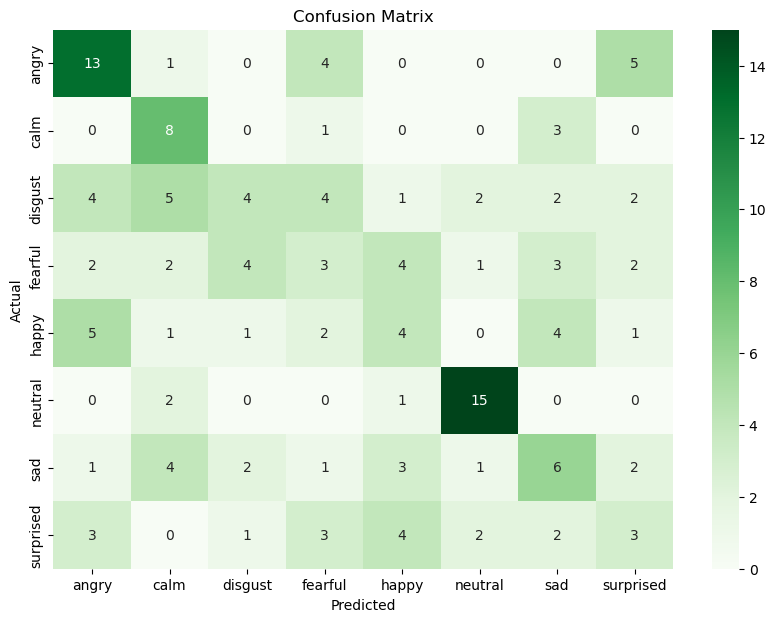

In [32]:
process.show_cmatrix(y_test, y_pred, y)

### Support Vector Machine

In [33]:
from sklearn.svm import SVC

In [34]:
# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)

In [35]:
# Train the classifier
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [36]:
# Predict on the test set
y_pred = svm_classifier.predict(X_test)

In [37]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.59
Classification Report:
              precision    recall  f1-score   support

       angry       0.71      0.74      0.72        23
        calm       0.50      0.75      0.60        12
     disgust       0.68      0.54      0.60        24
     fearful       0.62      0.48      0.54        21
       happy       0.69      0.61      0.65        18
     neutral       0.46      0.72      0.57        18
         sad       0.50      0.45      0.47        20
   surprised       0.60      0.50      0.55        18

    accuracy                           0.59       154
   macro avg       0.60      0.60      0.59       154
weighted avg       0.61      0.59      0.59       154



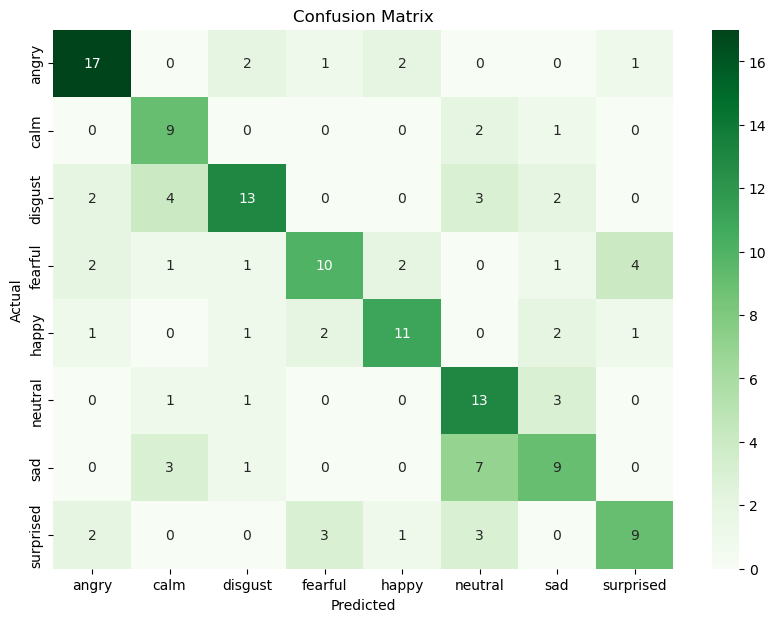

In [38]:
process.show_cmatrix(y_test, y_pred, y)

### K-Nearest Neighbor

In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
# set k
k = 3

In [48]:
# Initialize KNeighbors Classifier
knn = KNeighborsClassifier(n_neighbors=k)

In [49]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=8)

In [50]:
# Predict on the test set
y_pred = knn.predict(X_test)

In [51]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.47
Classification Report:
              precision    recall  f1-score   support

       angry       0.67      0.70      0.68        23
        calm       0.32      0.92      0.48        12
     disgust       0.75      0.25      0.38        24
     fearful       0.61      0.52      0.56        21
       happy       0.50      0.39      0.44        18
     neutral       0.33      0.50      0.40        18
         sad       0.58      0.35      0.44        20
   surprised       0.35      0.33      0.34        18

    accuracy                           0.47       154
   macro avg       0.52      0.49      0.46       154
weighted avg       0.54      0.47      0.47       154



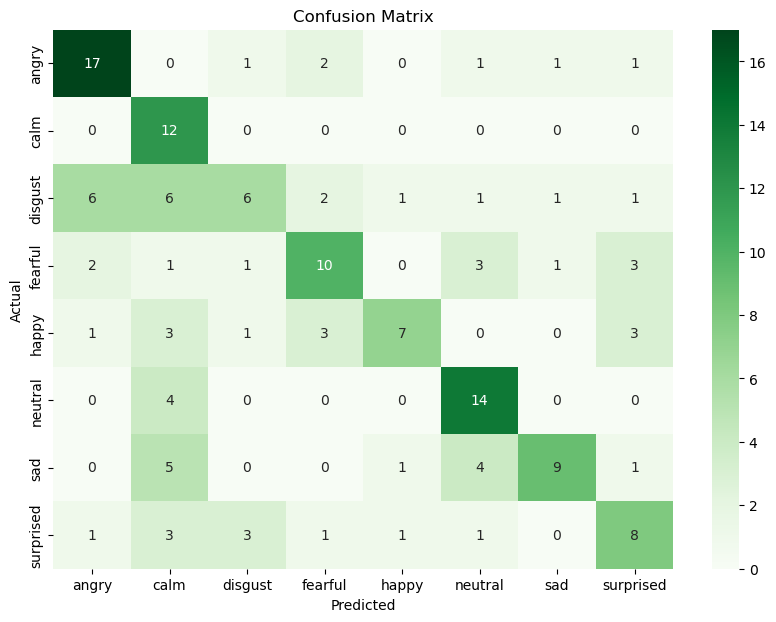

In [45]:
# k = 3
process.show_cmatrix(y_test, y_pred, y)

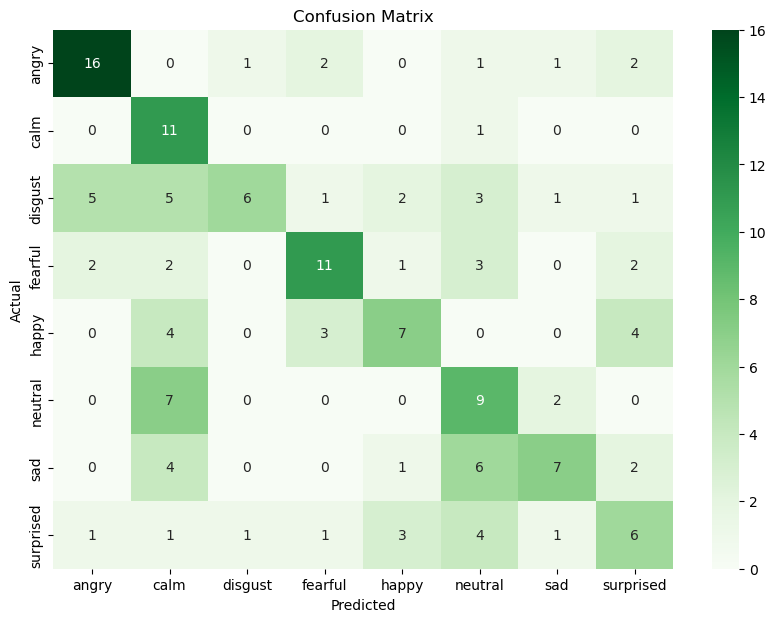

In [52]:
# k = 8
process.show_cmatrix(y_test, y_pred, y)

### Neural Network

In [53]:
# process/prepare data for NN model

file_dir = "data/"
X, y, class_names = process.process_data_nn(balanced_df, file_dir)
# feature_df.head()

['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [54]:
# Split data

test_size = 0.25
validation_size = 0.2
X_train, X_validation, X_test, y_train, y_validation, y_test = process.split_data_nn(X, y, test_size, validation_size)

In [55]:
# Check shape of X_train

X_train.shape

(460, 13, 216)

In [56]:
# Check values of y (labels)

y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [57]:
# define model

model = process.define_nn(X)

C:\Users\barry\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
# Train model
model.fit(X_train, y_train, epochs=30, validation_data = (X_validation, y_validation), batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1035 - loss: 357.1777 - val_accuracy: 0.1638 - val_loss: 54.3966
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2067 - loss: 37.7367 - val_accuracy: 0.3534 - val_loss: 9.2748
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3098 - loss: 7.5919 - val_accuracy: 0.4224 - val_loss: 4.1267
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4670 - loss: 3.3630 - val_accuracy: 0.3879 - val_loss: 4.1233
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5213 - loss: 3.1727 - val_accuracy: 0.5345 - val_loss: 3.2017
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6114 - loss: 1.9843 - val_accuracy: 0.5431 - val_loss: 3.4835
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6823 - loss: 1.6172 - val_accuracy: 0.4914 - val_loss: 2.9650
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7241 - loss: 1.1759 - val_accuracy: 0.5776

In [59]:
model.evaluate(X_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5833 - loss: 2.1216


[1.8574467897415161, 0.6145833134651184]

In [60]:
# Predict probabilities for each class
y_prob = model.predict(X_test)

# Convert probabilities to class labels by taking the argmax (for multi-class classification)
y_classes = y_prob.argmax(axis=-1)
y_classes

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


array([2, 3, 6, 5, 6, 2, 1, 6, 5, 1, 1, 2, 2, 2, 7, 3, 5, 7, 6, 6, 1, 5,
       0, 6, 1, 1, 6, 2, 7, 4, 5, 6, 4, 3, 7, 5, 6, 7, 6, 3, 7, 7, 7, 6,
       0, 0, 0, 0, 4, 5, 7, 5, 3, 4, 5, 3, 1, 5, 7, 3, 7, 0, 5, 1, 5, 1,
       2, 0, 2, 4, 0, 7, 5, 6, 6, 1, 7, 0, 5, 7, 6, 4, 6, 6, 1, 3, 1, 3,
       0, 3, 6, 3, 2, 4, 4, 7, 6, 5, 2, 0, 5, 3, 1, 6, 4, 6, 0, 7, 6, 3,
       1, 4, 7, 6, 4, 6, 5, 1, 1, 0, 2, 2, 0, 3, 0, 7, 7, 1, 6, 5, 0, 2,
       3, 1, 6, 4, 7, 5, 6, 6, 7, 7, 7, 5, 4, 1, 2, 0, 7, 7, 1, 6, 7, 4,
       0, 1, 5, 3, 0, 4, 5, 3, 4, 7, 3, 0, 1, 0, 2, 1, 0, 4, 2, 7, 2, 6,
       1, 3, 1, 1, 0, 1, 6, 7, 3, 1, 7, 1, 0, 6, 0, 6], dtype=int64)

In [61]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_classes)
report = classification_report(y_test, y_classes)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.61
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.63      0.69        30
           1       0.45      0.72      0.55        18
           2       0.82      0.48      0.61        29
           3       0.75      0.54      0.62        28
           4       0.59      0.53      0.56        19
           5       0.73      0.80      0.76        20
           6       0.56      0.69      0.62        26
           7       0.43      0.59      0.50        22

    accuracy                           0.61       192
   macro avg       0.64      0.62      0.61       192
weighted avg       0.65      0.61      0.62       192



In [62]:
confusion_matrix = tf.math.confusion_matrix(y_test, y_classes)

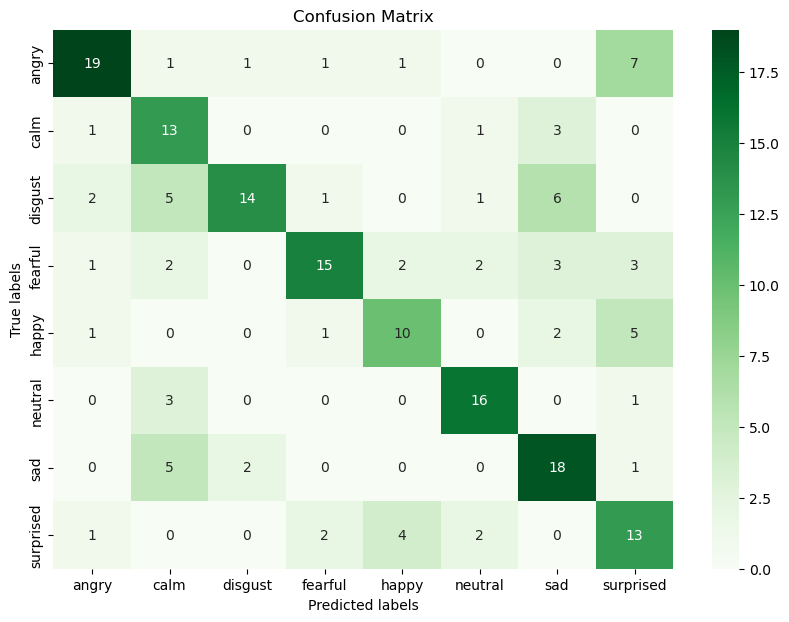

In [63]:
# Show confusion matrix

# class_names = ["angry", "calm", "disgust", "fearful", "happy", "neutral", "sad", "surprised"]
plt.figure(figsize=(10, 7))
fig = sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Greens')

fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)

plt.show()

### Notes

Lok, E. J. (2019). Audio Emotion | Part 1 - Explore data. Kaggle. https://www.kaggle.com/code/ejlok1/audio-emotion-part-1-explore-data 

Lok, E. J. (2019). Audio Emotion | Part 2 - Feature Extract. Kaggle. https://www.kaggle.com/code/ejlok1/audio-emotion-part-2-feature-extract 

Burnwal, S. (2020). Speech emotion recognition. Kaggle. https://www.kaggle.com/code/shivamburnwal/speech-emotion-recognition/notebook 

Clariño, M. A. A. D., & Alfonso, M. M. (2016). Evaluation of speech emotion recognition based on support vector machines with Gaussian mixture model super vectors1. Journal of Science, Technology, and Arts Research, 3, 25-34. https://national-u.edu.ph/wp-content/uploads/2016/08/JSTAR-3_Clarino.pdf 

In [21]:
balanced_df.shape

(1536, 8)

In [20]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   File_Name   1536 non-null   object 
 1   Actor       1536 non-null   int64  
 2   Gender      1536 non-null   object 
 3   Emotion     1536 non-null   object 
 4   Intensity   1536 non-null   object 
 5   Statement   1536 non-null   int64  
 6   Repetition  1536 non-null   int64  
 7   length      1536 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 96.1+ KB


In [19]:
df.tail(20)

,File_Name,Actor,Gender,Emotion,Intensity,Statement,Repetition
1420,03-01-06-02-01-01-24.wav,24,F,fearful,strong,1,1
1421,03-01-06-02-01-02-24.wav,24,F,fearful,strong,1,2
1422,03-01-06-02-02-01-24.wav,24,F,fearful,strong,2,1
1423,03-01-06-02-02-02-24.wav,24,F,fearful,strong,2,2
1424,03-01-07-01-01-01-24.wav,24,F,disgust,normal,1,1
1425,03-01-07-01-01-02-24.wav,24,F,disgust,normal,1,2
1426,03-01-07-01-02-01-24.wav,24,F,disgust,normal,2,1
1427,03-01-07-01-02-02-24.wav,24,F,disgust,normal,2,2
1428,03-01-07-02-01-01-24.wav,24,F,disgust,strong,1,1
1429,03-01-07-02-01-02-24.wav,24,F,disgust,strong,1,2


In [29]:
feature_df.tail(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,Emotion,Gender
1516,-521.708862,105.027802,-6.167501,25.992083,-0.561827,12.506777,-11.740922,1.565715,-15.875378,-5.955151,-8.195910,-9.992088,-0.897106,82.265001,32.543824,surprised,M
1517,-522.670410,83.548126,-19.119108,22.365358,2.148286,16.005682,-10.975065,3.482453,-18.521450,-2.557602,-13.151992,-2.305750,0.255746,70.899598,30.803679,surprised,M
1518,-587.201660,101.808937,0.976507,21.695023,1.598882,9.119096,-8.974477,5.340245,-12.550219,-4.036747,-4.191584,-2.160835,-1.104753,54.371139,32.523178,surprised,M
1519,-644.491028,89.280144,7.019996,28.838940,0.498665,10.108649,-1.206587,10.147071,-12.485368,-0.576983,-4.277468,-2.828282,2.416450,59.322446,25.138864,surprised,M
1520,-512.589539,99.083611,-2.303137,12.386011,4.203571,14.668574,-17.507378,0.990570,-5.641875,-10.434600,-11.205260,0.108939,-6.464543,53.021680,28.691412,surprised,M
1521,-527.400696,92.152473,-1.934756,13.436055,3.137017,13.539573,-14.603951,3.241038,-3.848999,-9.271966,-10.580489,-1.207237,-5.720273,57.391136,26.556983,surprised,M
1522,-512.814514,86.243492,-7.710720,11.071899,3.454062,11.878888,-14.457660,1.976596,-8.196171,-10.153270,-10.177957,-0.363153,-7.675332,56.478605,26.943142,surprised,M
1523,-485.051605,90.195839,0.585444,14.942048,2.880083,11.997249,-13.617034,0.733678,-3.788407,-11.708426,-7.584818,-1.121703,-7.291596,51.417223,28.817619,surprised,M
1524,-466.962097,89.450836,-11.998470,14.639668,3.537050,11.962321,-16.864332,-2.751358,-5.931911,-11.923776,-15.521055,1.350211,-7.215192,65.346081,31.235524,surprised,M
1525,-464.858002,101.257599,-16.433805,14.504876,4.509501,10.780073,-20.141008,-2.446599,-6.520892,-9.761683,-17.317659,-0.252178,-7.390106,66.813764,30.837151,surprised,M
